# Notebook 02 — Decision Tree
  **Regression** → Predict WQI
  **Classification** → Predict Water Quality Category

  ### Why Decision Tree?
  - Learns by asking YES/NO questions on features: "Is pH > 7.5? Is TDS > 500?"
  - Captures **non-linear relationships** unlike Linear Regression
  - Fully interpretable — you can visualize exactly how decisions are made
  - Tends to **overfit** (memorize training data) — we'll see this in train vs test scores
  - Sets the foundation for understanding Random Forest (many trees together)


In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
  r2_score, mean_squared_error, mean_absolute_error,
  accuracy_score, f1_score, classification_report, confusion_matrix
)



In [3]:
with open('processed_data.pkl', 'rb') as f:
  data = pickle.load(f)

X_train       = data['X_train']
X_test        = data['X_test']
y_reg_train   = data['y_reg_train']
y_reg_test    = data['y_reg_test']
y_clf_train   = data['y_clf_train']
y_clf_test    = data['y_clf_test']
le            = data['label_encoder']
feature_names = data['feature_names']

print("Train size:", X_train.shape)
print("Test  size:", X_test.shape)

Train size: (15223, 30)
Test  size: (3806, 30)


## Part 1 — Decision Tree Regressor (Predict WQI)

The tree splits data by asking questions on features.
At each leaf node, it predicts the **average WQI** of all samples that fell there.

Key parameter: `max_depth`
- No limit → tree memorizes every training sample → R² Train = 1.0 but Test drops
- Limited depth → forces generalization

In [6]:
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train, y_reg_train)

y_pred_train = dt_reg.predict(X_train)
y_pred_test  = dt_reg.predict(X_test)

r2_train = r2_score(y_reg_train, y_pred_train)
r2_test  = r2_score(y_reg_test,  y_pred_test)
rmse     = np.sqrt(mean_squared_error(y_reg_test, y_pred_test))
mae      = mean_absolute_error(y_reg_test, y_pred_test)

print("=== Decision Tree Regressor (No Depth Limit) ===")
print(f"R² Train : {r2_train:.4f}   ← likely 1.0 (overfitting)")
print(f"R² Test  : {r2_test:.4f}")
print(f"RMSE     : {rmse:.2f}")
print(f"MAE      : {mae:.2f}")
print(f"Tree Depth: {dt_reg.get_depth()}")

=== Decision Tree Regressor (No Depth Limit) ===
R² Train : 1.0000   ← likely 1.0 (overfitting)
R² Test  : 0.9919
RMSE     : 29.12
MAE      : 8.97
Tree Depth: 31


 ### Observing Overfitting — Depth vs R² Score
  Let's see how train and test R² change as we limit the tree depth.
  This is called a **Validation Curve** — a key concept in ML.

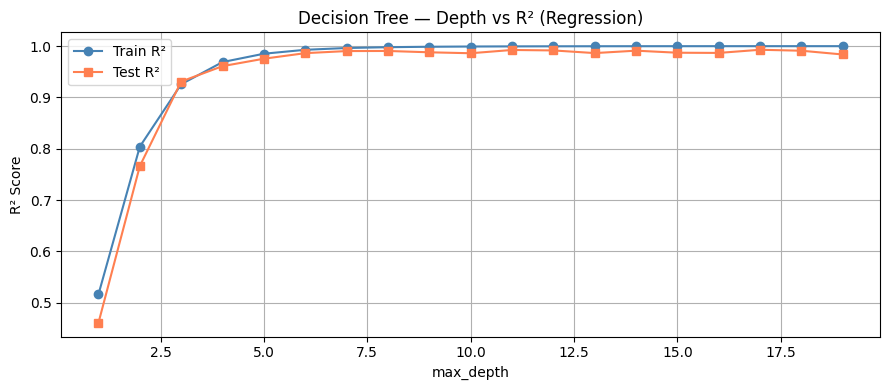

In [7]:
depths = range(1, 20)
train_scores = []
test_scores  = []

for d in depths:
  m = DecisionTreeRegressor(max_depth=d, random_state=42)
  m.fit(X_train, y_reg_train)
  train_scores.append(r2_score(y_reg_train, m.predict(X_train)))
  test_scores.append(r2_score(y_reg_test,   m.predict(X_test)))

plt.figure(figsize=(9, 4))
plt.plot(depths, train_scores, marker='o', label='Train R²', color='steelblue')
plt.plot(depths, test_scores,  marker='s', label='Test R²',  color='coral')
plt.xlabel('max_depth')
plt.ylabel('R² Score')
plt.title('Decision Tree — Depth vs R² (Regression)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [15]:
best_depth_reg = test_scores.index(max(test_scores)) + 1
print(f"Best max_depth for Regression: {best_depth_reg}")

dt_reg_best = DecisionTreeRegressor(max_depth=best_depth_reg, random_state=42)
dt_reg_best.fit(X_train, y_reg_train)

r2_train_best = r2_score(y_reg_train, dt_reg_best.predict(X_train))
r2_test_best  = r2_score(y_reg_test,  dt_reg_best.predict(X_test))
rmse_best     = np.sqrt(mean_squared_error(y_reg_test, dt_reg_best.predict(X_test)))

print(f"R² Train : {r2_train_best:.4f}")
print(f"R² Test  : {r2_test_best:.4f}")
print(f"RMSE     : {rmse_best:.2f}")

Best max_depth for Regression: 17
R² Train : 1.0000
R² Test  : 0.9930
RMSE     : 27.20


### What depth 17 tells you:
  
  The tree needed 17 levels of questions to best generalize. That's a fairly deep tree, which means:
  - WQI has complex, non-linear relationships with the features
  - A shallow tree (depth 3–4) would miss important splits

## Part 2 — Decision Tree Classifier (Predict Water Quality)

  Same tree structure, but at each leaf node it predicts the **majority class**
  instead of the average value.


In [8]:
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_clf_train)

acc_train = accuracy_score(y_clf_train, dt_clf.predict(X_train))
acc_test  = accuracy_score(y_clf_test,  dt_clf.predict(X_test))
f1_test   = f1_score(y_clf_test, dt_clf.predict(X_test), average='weighted')

print("=== Decision Tree Classifier (No Depth Limit) ===")
print(f"Accuracy Train : {acc_train:.4f}   ← likely 1.0 (overfitting)")
print(f"Accuracy Test  : {acc_test:.4f}")
print(f"F1 Score Test  : {f1_test:.4f}")
print(f"Tree Depth     : {dt_clf.get_depth()}")

=== Decision Tree Classifier (No Depth Limit) ===
Accuracy Train : 1.0000   ← likely 1.0 (overfitting)
Accuracy Test  : 0.9540
F1 Score Test  : 0.9540
Tree Depth     : 18


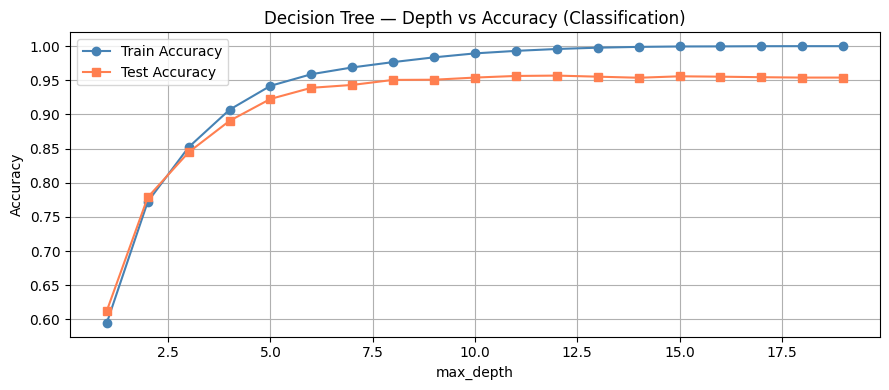

In [9]:
train_acc, test_acc = [], []

for d in depths:
  m = DecisionTreeClassifier(max_depth=d, random_state=42)
  m.fit(X_train, y_clf_train)
  train_acc.append(accuracy_score(y_clf_train, m.predict(X_train)))
  test_acc.append(accuracy_score(y_clf_test,   m.predict(X_test)))

plt.figure(figsize=(9, 4))
plt.plot(depths, train_acc, marker='o', label='Train Accuracy', color='steelblue')
plt.plot(depths, test_acc,  marker='s', label='Test Accuracy',  color='coral')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree — Depth vs Accuracy (Classification)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
best_depth_clf = test_acc.index(max(test_acc)) + 1
print(f"Best max_depth for Classification: {best_depth_clf}")

dt_clf_best = DecisionTreeClassifier(max_depth=best_depth_clf, random_state=42)
dt_clf_best.fit(X_train, y_clf_train)

y_clf_pred = dt_clf_best.predict(X_test)
acc_test_best = accuracy_score(y_clf_test, y_clf_pred)
f1_test_best  = f1_score(y_clf_test, y_clf_pred, average='weighted')

print(f"Accuracy Test : {acc_test_best:.4f}")
print(f"F1 Score Test : {f1_test_best:.4f}")
print("\n", classification_report(y_clf_test, y_clf_pred, target_names=le.classes_))

Best max_depth for Classification: 12
Accuracy Test : 0.9569
F1 Score Test : 0.9570

                          precision    recall  f1-score   support

              Excellent       0.92      0.95      0.93       136
                   Good       0.90      0.93      0.92       317
                   Poor       0.96      0.95      0.96      1066
Unsuitable for Drinking       0.98      0.98      0.98      1370
Very Poor yet Drinkable       0.94      0.95      0.94       917

               accuracy                           0.96      3806
              macro avg       0.94      0.95      0.95      3806
           weighted avg       0.96      0.96      0.96      3806



Accuracy vs F1 are almost equal (0.9569 vs 0.9570)
  
  This is a good sign. It means:
  The model performs consistently across all classes
  No single large class is inflating the accuracy score
  If accuracy was 0.95 but F1 was 0.80, that would mean the model is good on large classes but terrible
  on small ones like "Excellent".


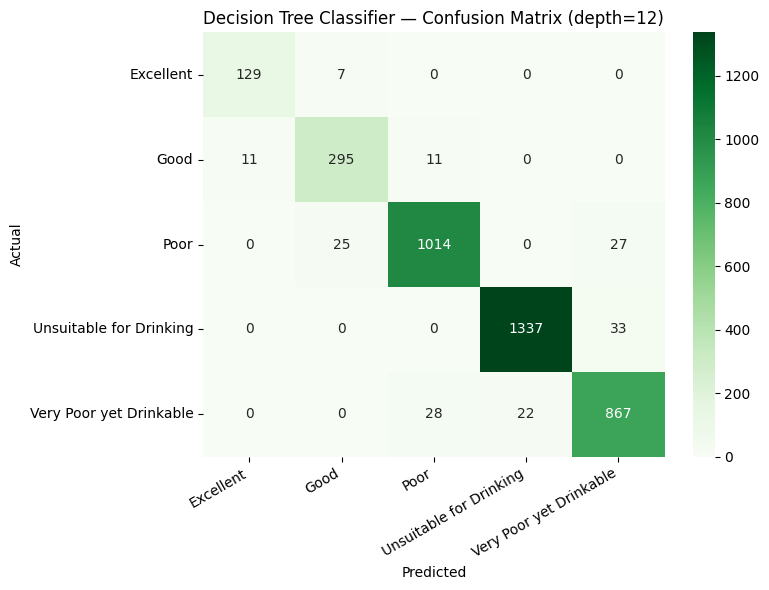

In [11]:
cm = confusion_matrix(y_clf_test, y_clf_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
          xticklabels=le.classes_,
          yticklabels=le.classes_)
plt.title(f'Decision Tree Classifier — Confusion Matrix (depth={best_depth_clf})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


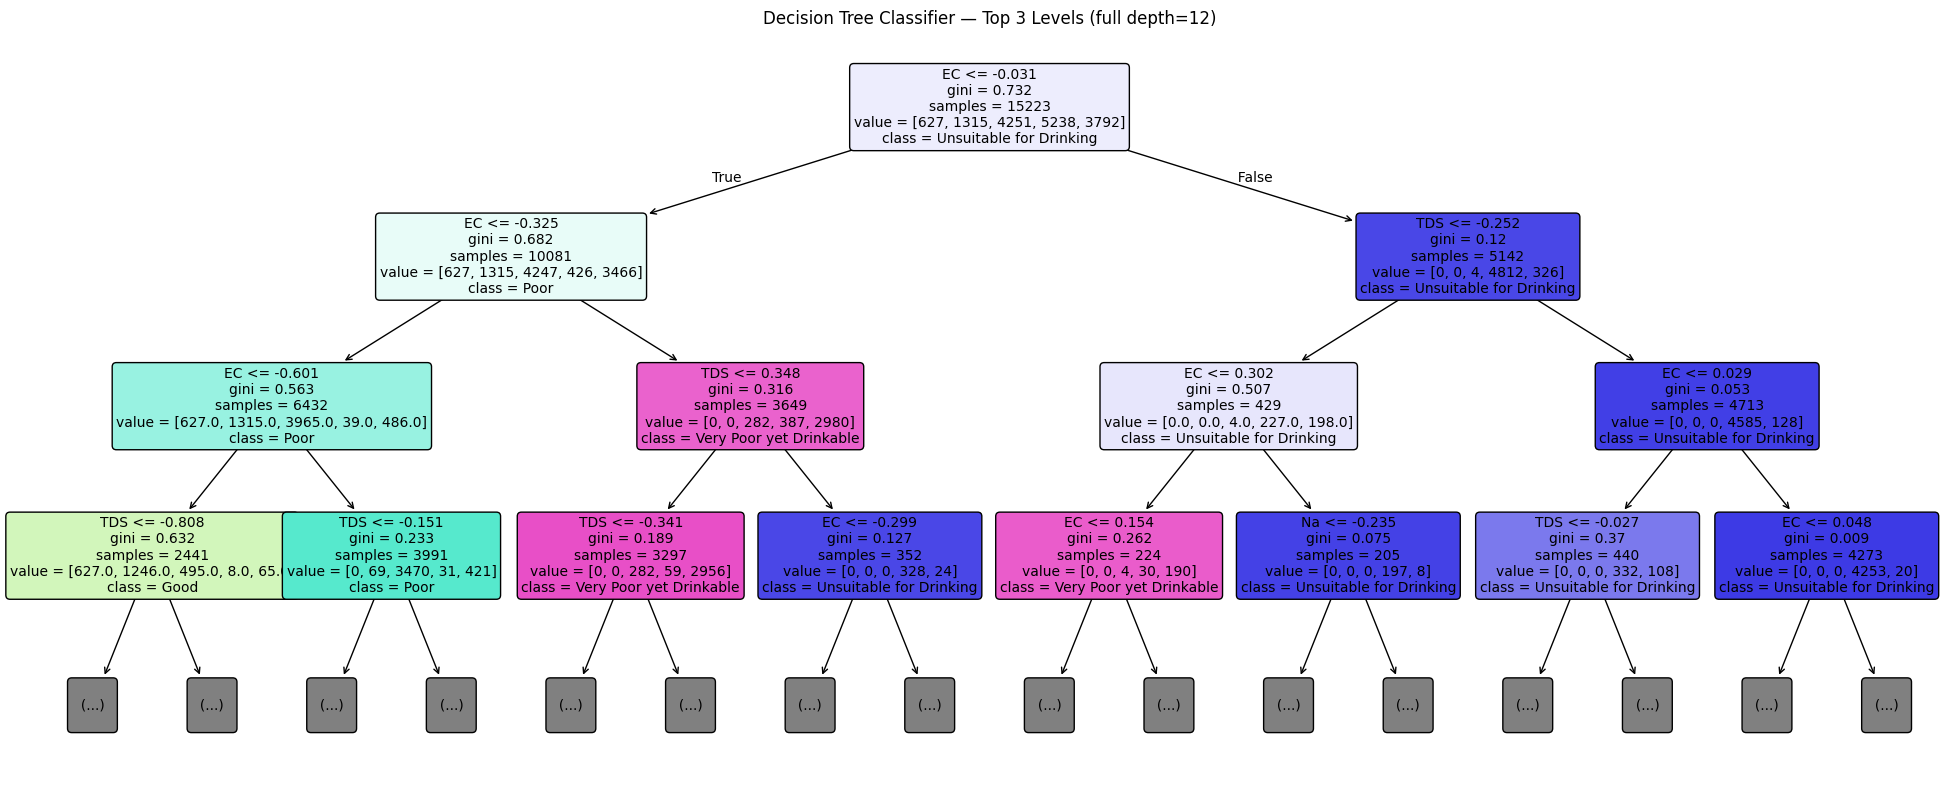

In [20]:
#Visualize Decision Tree (Classification)
plt.figure(figsize=(20, 8))
plot_tree(
  dt_clf_best,
  max_depth=3,          # show only top 3 levels — full tree is too large
  feature_names=feature_names,
  class_names=le.classes_,
  filled=True,          # color nodes by majority class
  rounded=True,
  fontsize=10
)
plt.title(f'Decision Tree Classifier — Top 3 Levels (full depth={best_depth_clf})')
plt.tight_layout()
plt.show()


What you will see:

Each box (node) shows:
├── Feature name and split condition  e.g. "EC <= 1.23"
├── Gini impurity  (0 = pure node, 0.5 = mixed)
├── Samples        (how many training samples reached this node)
├── Value          (count per class)
└── Class          (majority class at this node)

---
Why max_depth=3 not 12?

The full tree at depth 12 has thousands of nodes — it becomes unreadable. Showing the top 3 levels
reveals the most important splits (the questions the tree asks first are the most powerful ones).

---
Colors in the plot:

Each class gets a unique color. Darker shade = purer node (one class dominates). Light/white nodes are
mixed and need more splitting to separate.

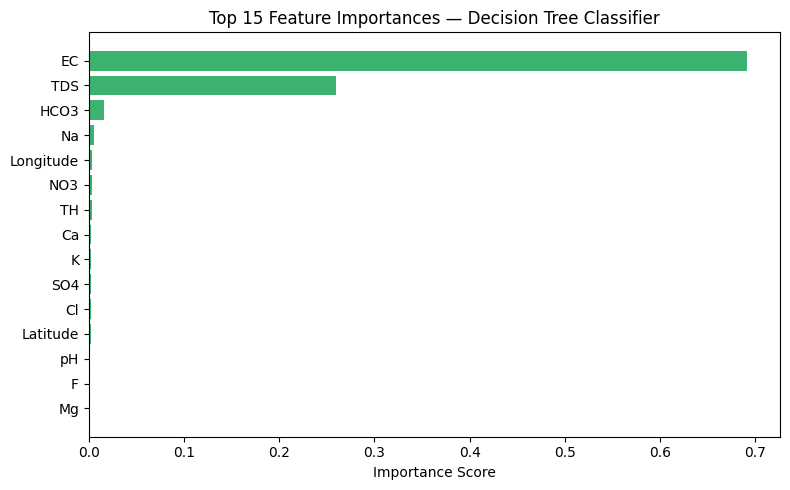

In [12]:
importances = dt_clf_best.feature_importances_
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='mediumseagreen')
plt.title('Top 15 Feature Importances — Decision Tree Classifier')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [16]:
summary = pd.DataFrame([
  {
      'Model': 'Decision Tree (default)',
      'Task': 'Regression (WQI)',
      'Train Score': f"R² = {r2_train:.4f}",
      'Test Score':  f"R² = {r2_test:.4f}",
      'Note': 'Overfit'
  },
  {
      'Model': f'Decision Tree (depth={best_depth_reg})',
      'Task': 'Regression (WQI)',
      'Train Score': f"R² = {r2_train_best:.4f}",
      'Test Score':  f"R² = {r2_test_best:.4f}",
      'Note': 'Best depth'
  },
  {
      'Model': 'Decision Tree (default)',
      'Task': 'Classification',
      'Train Score': f"Acc = {acc_train:.4f}",
      'Test Score':  f"Acc = {acc_test:.4f}",
      'Note': 'Overfit'
  },
  {
      'Model': f'Decision Tree (depth={best_depth_clf})',
      'Task': 'Classification',
      'Train Score': f"Acc = —",
      'Test Score':  f"Acc = {acc_test_best:.4f}  F1 = {f1_test_best:.4f}",
      'Note': 'Best depth'
  }
])

summary

,Model,Task,Train Score,Test Score,Note
0,Decision Tree (default),Regression (WQI),R² = 1.0000,R² = 0.9919,Overfit
1,Decision Tree (depth=17),Regression (WQI),R² = 1.0000,R² = 0.9930,Best depth
2,Decision Tree (default),Classification,Acc = 1.0000,Acc = 0.9540,Overfit
3,Decision Tree (depth=12),Classification,Acc = —,Acc = 0.9569 F1 = 0.9570,Best depth


In [17]:
results = {
  'Decision Tree Regression': {
      'r2_train': r2_train_best,
      'r2_test':  r2_test_best,
      'rmse':     rmse_best
  },
  'Decision Tree Classification': {
      'acc_test': acc_test_best,
      'f1_test':  f1_test_best
  }
}

with open('results_02_decision_tree.pkl', 'wb') as f:
  pickle.dump(results, f)

print("Saved. Move on to 03_Random_Forest.ipynb")

Saved. Move on to 03_Random_Forest.ipynb
